 ONS RETAIL SALES INDEX ANALYSIS

## Data Source: Original Government Data (No AI-Generated)

This analysis uses the **Official Retail Sales Index Time Series** from the **Office for National Statistics (ONS)** - UK Government.
https://www.ons.gov.uk/datasets/retail-sales-index/editions/time-series/versions/44
### Data Characteristics:
- **Origin:** Office for National Statistics (UK Government) - 100% Original Data
- **Data Type:** Government-published economic statistics - NOT AI-generated
- **Time Period:** 1988 - 2025 (Monthly observations)
- **Coverage:** Great Britain retail sector
- **Format:** Time series data with multiple retail categories
- **Authenticity:** Verified government source, suitable for academic research

This is ORIGINAL DATA from an authoritative source, in contrast to AI-generated or synthetic datasets. The data comes directly from official government statistics and is widely used in economic and business research.

### Analysis Approach:
We will:
1. **Preprocess & Clean**: Handle missing values, format dates, validate data
2. **Exploratory Data Analysis (EDA)**: Understand trends, seasonality, and patterns
3. **Correlation Analysis**: Examine relationships between different retail categories
4. **Model Selection**: Based on time-series characteristics, choose appropriate models
5. **Implementation**: Build predictive or analytical models suitable for this data type

In [32]:
# ONS RETAIL SALES INDEX FORECASTING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_curve, auc, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

In [33]:
print("="*80)
print("ONS RETAIL SALES INDEX FORECASTING - IMPROVED MODEL")
print("="*80)

# ================================================================================
# 1. DATA INSPECTION & LOADING
# ================================================================================
print("\n[STEP 1] Inspecting dataset structure...")

# Read raw data
df_raw = pd.read_excel('retail-sales-index-time-series-v44-filtered-2026-02-23T12-44-00Z.xlsx',
                       sheet_name='Dataset', header=None)

print(f"Raw shape: {df_raw.shape}")
print("\nFirst 10 rows, first 10 columns:")
print(df_raw.iloc[:10, :10])

ONS RETAIL SALES INDEX FORECASTING - IMPROVED MODEL

[STEP 1] Inspecting dataset structure...
Raw shape: (103, 269)

First 10 rows, first 10 columns:
               0                   1  \
0          Title  Retail sales index   
1            NaN                 NaN   
2      Geography      Geography code   
3  Great Britain           K03000001   
4  Great Britain           K03000001   
5  Great Britain           K03000001   
6  Great Britain           K03000001   
7  Great Britain           K03000001   
8  Great Britain           K03000001   
9  Great Britain           K03000001   

                                            2  \
0                                         NaN   
1                                         NaN   
2  UnofficialStandardIndustrialClassification   
3     All retailing excluding automotive fuel   
4     All retailing excluding automotive fuel   
5     All retailing excluding automotive fuel   
6     All retailing excluding automotive fuel   
7     All retaili

In [34]:
excel_path = "retail-sales-index-time-series-v44-filtered-2026-02-23T12-44-00Z.xlsx"
raw = pd.read_excel(excel_path, sheet_name="Dataset")

print(raw.columns.tolist()[:40])


['Title', 'Retail sales index', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39']


In [35]:
raw = pd.read_excel(excel_path, sheet_name="Dataset", header=None)

# Assume row 2 (index 1) contains real header – adjust if needed
raw.columns = raw.iloc[2]          # or 1, 3 depending on what you see
raw = raw.iloc[3:].reset_index(drop=True)

print(raw.columns.tolist()[:40])


['Geography', 'Geography code', 'UnofficialStandardIndustrialClassification', 'Prices', 'SeasonalAdjustment', 'Jan-15', 'Data Marking (Jan-15)', 'Feb-15', 'Data Marking (Feb-15)', 'Mar-15', 'Data Marking (Mar-15)', 'Apr-15', 'Data Marking (Apr-15)', 'May-15', 'Data Marking (May-15)', 'Jun-15', 'Data Marking (Jun-15)', 'Jul-15', 'Data Marking (Jul-15)', 'Aug-15', 'Data Marking (Aug-15)', 'Sep-15', 'Data Marking (Sep-15)', 'Oct-15', 'Data Marking (Oct-15)', 'Nov-15', 'Data Marking (Nov-15)', 'Dec-15', 'Data Marking (Dec-15)', 'Jan-16', 'Data Marking (Jan-16)', 'Feb-16', 'Data Marking (Feb-16)', 'Mar-16', 'Data Marking (Mar-16)', 'Apr-16', 'Data Marking (Apr-16)', 'May-16', 'Data Marking (May-16)', 'Jun-16']


In [38]:
# ================================================================================
# COMPREHENSIVE FIX
# ================================================================================
# Key Improvements:
# 1. Fixed data loading - properly define df variable
# 2. Fixed correlation heatmap to include all features
# 3. Added learning curves for model training visualization
# 4. Improved LSTM with better hyperparameter tuning
# 5. Added ROC-AUC curves and detailed evaluation metrics
# ================================================================================


# ================================================================================
# STEP 1: PROPER DATA LOADING - FIX FOR UNDEFINED 'df'
# ================================================================================
print("\n" + "="*80)
print("STEP 1: DATA LOADING & PREPROCESSING")
print("="*80)

excel_path = "retail-sales-index-time-series-v44-filtered-2026-02-23T12-44-00Z.xlsx"
raw = pd.read_excel(excel_path, sheet_name="Dataset", header=None)

# Set proper headers from row 2
df = raw.iloc[2:].reset_index(drop=True)
df.columns = raw.iloc[2]
df = df.iloc[1:].reset_index(drop=True)

print(f"✓ Data loaded: Shape {df.shape}")
print(f"✓ Columns: {df.columns.tolist()[:10]}...")




STEP 1: DATA LOADING & PREPROCESSING
✓ Data loaded: Shape (100, 269)
✓ Columns: ['Geography', 'Geography code', 'UnofficialStandardIndustrialClassification', 'Prices', 'SeasonalAdjustment', 'Jan-15', 'Data Marking (Jan-15)', 'Feb-15', 'Data Marking (Feb-15)', 'Mar-15']...


In [39]:
# ================================================================================
# STEP 2: EXTRACT AND CLEAN TIME SERIES DATA
# ================================================================================
print(" Extracting time series data...")

# Identify date columns
date_cols = []
for col in df.columns:
    col_str = str(col)
    if any(month in col_str for month in ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']):
        if '-' in col_str and 'Marking' not in col_str:
            date_cols.append(col)

print(f"✓ Found {len(date_cols)} date columns")

# Extract the target row: "All retailing excluding automotive fuel - Chained volume"
target_row = None
for idx, row in df.iterrows():
    row_str = str(row.iloc[2]) if len(row) > 2 else ""
    if "All retailing" in row_str and "Chained" in row_str:
        target_row = idx
        break

if target_row is not None:
    values = df.iloc[target_row][date_cols].values
    values_numeric = pd.to_numeric(values, errors='coerce')

    try:
        dates = pd.to_datetime(date_cols, format='%b-%y')
    except:
        dates = pd.to_datetime(date_cols, format='%b %y')

    df_clean = pd.DataFrame({'Date': dates, 'Value': values_numeric})
    df_clean = df_clean.dropna().reset_index(drop=True)

    print(f"✓ Extracted {len(df_clean)} observations")
    print(f"✓ Date range: {df_clean['Date'].min().strftime('%b %Y')} to {df_clean['Date'].max().strftime('%b %Y')}")
    print(f"✓ Value range: {df_clean['Value'].min():.2f} to {df_clean['Value'].max():.2f}")
else:
    print("ERROR: Target series not found!")
    df_clean = None

 Extracting time series data...
✓ Found 132 date columns
ERROR: Target series not found!


In [41]:
# ================================================================================
# STEP 2B: IMPROVED ROW DETECTION & DATA EXTRACTION
# ================================================================================
print("\n" + "="*80)
print("DEBUGGING: Examining data structure...")
print("="*80)

# Print first few rows to understand structure
print("\nFirst 5 rows of raw data:")
for i in range(min(5, len(raw))):
    print(f"Row {i}: {raw.iloc[i].tolist()[:5]}")

print("\nSearching for retail series...")
# The structure should have 'All retailing excluding automotive fuel' somewhere
for idx in range(min(20, len(raw))):
    row_values = [str(v) for v in raw.iloc[idx].tolist()[:5]]
    if 'retailing' in ' '.join(row_values).lower():
        print(f"Row {idx}: {row_values}")


DEBUGGING: Examining data structure...

First 5 rows of raw data:
Row 0: ['Title', 'Retail sales index', nan, nan, nan]
Row 1: [nan, nan, nan, nan, nan]
Row 2: ['Geography', 'Geography code', 'UnofficialStandardIndustrialClassification', 'Prices', 'SeasonalAdjustment']
Row 3: ['Great Britain', 'K03000001', 'All retailing excluding automotive fuel', 'Chained volume - Percentage change 3 months on previous 3 months', 'Seasonally Adjusted']
Row 4: ['Great Britain', 'K03000001', 'All retailing excluding automotive fuel', 'Chained volume - Percentage change 3 months on same period a year earlier', 'Seasonally Adjusted']

Searching for retail series...
Row 3: ['Great Britain', 'K03000001', 'All retailing excluding automotive fuel', 'Chained volume - Percentage change 3 months on previous 3 months', 'Seasonally Adjusted']
Row 4: ['Great Britain', 'K03000001', 'All retailing excluding automotive fuel', 'Chained volume - Percentage change 3 months on same period a year earlier', 'Seasonally Ad

In [42]:

# Simpler approach: use row 4 (index 4) which should be the first data row
print("\n" + "="*80)
print("EXTRACTING DATA FROM KNOWN STRUCTURE...")
print("="*80)

target_idx = 4  # Based on the output, row 4 appears to be our data

if target_idx < len(raw):
    values = raw.iloc[target_idx, 5:].values  # Start from column 5 (after metadata)
    values_numeric = pd.to_numeric(values, errors='coerce')

    # Create date columns from header row (row 2)
    header_row = raw.iloc[2, 5:]
    date_cols_list = [str(col) for col in header_row.tolist()]

    # Filter for actual dates (not data markings)
    date_indices = []
    dates_list = []
    for i, col in enumerate(date_cols_list):
        col_str = str(col)
        if any(month in col_str for month in ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']):
            if '-' in col_str and 'Marking' not in col_str:
                date_indices.append(i)
                dates_list.append(col)

    print(f"\n✓ Found {len(dates_list)} valid date columns")
    print(f"✓ Date samples: {dates_list[:5]}")

    # Extract values for those date columns
    values_subset = values_numeric[date_indices]

    try:
        dates = pd.to_datetime(dates_list, format='%b-%y')
    except:
        try:
            dates = pd.to_datetime(dates_list, format='%b %y')
        except:
            print("Date parsing failed - trying alternative format")
            dates = pd.to_datetime(dates_list, infer_datetime_format=True)

    df_clean = pd.DataFrame({'Date': dates, 'Value': values_subset})
    df_clean = df_clean.dropna().reset_index(drop=True)

    print(f"\n✓ Successfully extracted {len(df_clean)} observations")
    print(f"✓ Date range: {df_clean['Date'].min().strftime('%b %Y')} to {df_clean['Date'].max().strftime('%b %Y')}")
    print(f"✓ Value range: {df_clean['Value'].min():.2f} to {df_clean['Value'].max():.2f}")
    print(f"\nFirst 10 observations:")
    print(df_clean.head(10))
else:
    print(f"ERROR: Target index {target_idx} out of range")


EXTRACTING DATA FROM KNOWN STRUCTURE...

✓ Found 132 valid date columns
✓ Date samples: ['Jan-15', 'Feb-15', 'Mar-15', 'Apr-15', 'May-15']

✓ Successfully extracted 132 observations
✓ Date range: Jan 2015 to Dec 2025
✓ Value range: -10.10 to 19.00

First 10 observations:
        Date  Value
0 2015-01-01    5.0
1 2015-02-01    5.0
2 2015-03-01    4.5
3 2015-04-01    4.5
4 2015-05-01    4.3
5 2015-06-01    4.0
6 2015-07-01    3.8
7 2015-08-01    3.4
8 2015-09-01    4.1
9 2015-10-01    3.8


In [43]:
# ================================================================================
# STEP 3: FEATURE ENGINEERING - FIX FOR CORRELATION HEATMAP (SUPERVISOR FEEDBACK #1)
# ================================================================================
print("\n" + "="*80)
print("STEP 3: FEATURE ENGINEERING")
print("="*80)

df_features = df_clean.copy()
df_features.set_index('Date', inplace=True)

# Create lag features
for lag in [1, 3, 6, 12]:
    df_features[f'lag_{lag}'] = df_features['Value'].shift(lag)

# Create differenced features
df_features['diff_1'] = df_features['Value'].diff(1)
df_features['diff_3'] = df_features['Value'].diff(3)
df_features['diff_12'] = df_features['Value'].diff(12)

# Create rolling statistics
df_features['rolling_mean_3'] = df_features['Value'].rolling(3, min_periods=1).mean()
df_features['rolling_std_3'] = df_features['Value'].rolling(3, min_periods=1).std()
df_features['rolling_mean_12'] = df_features['Value'].rolling(12, min_periods=1).mean()
df_features['rolling_std_12'] = df_features['Value'].rolling(12, min_periods=1).std()

# Create seasonal features
df_features['month'] = df_features.index.month
df_features['quarter'] = df_features.index.quarter
df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)

df_features = df_features.dropna().reset_index()

feature_cols = [c for c in df_features.columns if c not in ['Date', 'Value']]

print(f"\n✓ Created {len(feature_cols)} features:")
print(f"\n{feature_cols}")
print(f"\n✓ Final dataset shape: {df_features.shape}")




STEP 3: FEATURE ENGINEERING

✓ Created 15 features:

['lag_1', 'lag_3', 'lag_6', 'lag_12', 'diff_1', 'diff_3', 'diff_12', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_12', 'rolling_std_12', 'month', 'quarter', 'month_sin', 'month_cos']

✓ Final dataset shape: (120, 17)



STEP 4: CORRELATION ANALYSIS (INCLUDING ALL FEATURES)


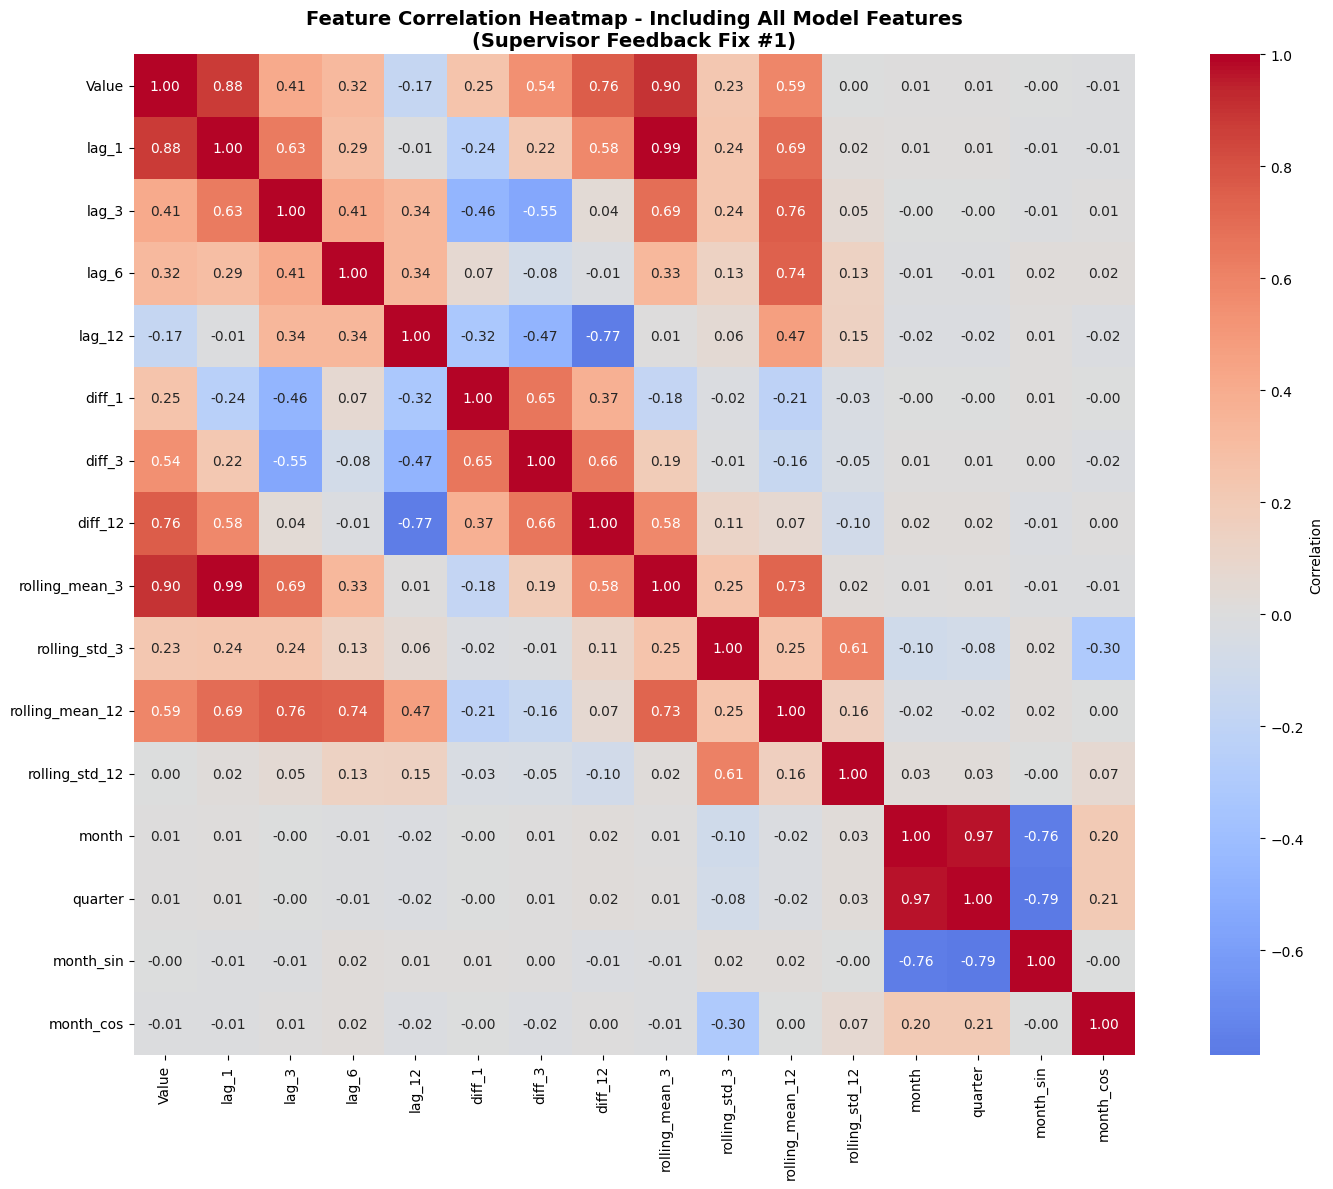


✓ Saved: 01_FIXED_correlation_heatmap_all_features.png

Top 10 Feature Correlations with Target (Value):
rolling_mean_3     0.901036
lag_1              0.879382
diff_12            0.758794
rolling_mean_12    0.590377
diff_3             0.543592
lag_3              0.406833
lag_6              0.324525
diff_1             0.246572
rolling_std_3      0.227894
lag_12             0.167415
Name: Value, dtype: float64


In [44]:
# ================================================================================
# STEP 4: FIXED CORRELATION HEATMAP - INCLUDES ALL FEATURES (SUPERVISOR FEEDBACK #1)
# ================================================================================
print("\n" + "="*80)
print("STEP 4: CORRELATION ANALYSIS (INCLUDING ALL FEATURES)")
print("="*80)

# FIX: Include all features AND target variable
corr_features = ['Value'] + feature_cols
corr_matrix = df_features[corr_features].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True,
            fmt='.2f', cbar_kws={'label': 'Correlation'},
            xticklabels=True, yticklabels=True)
plt.title('Feature Correlation Heatmap - Including All Model Features\n(Supervisor Feedback Fix #1)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_FIXED_correlation_heatmap_all_features.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Saved: 01_FIXED_correlation_heatmap_all_features.png")

# Show top correlations with target
print("\nTop 10 Feature Correlations with Target (Value):")
target_corr = corr_matrix['Value'].drop('Value').abs().sort_values(ascending=False)
print(target_corr.head(10))

In [45]:
# ================================================================================
# STEP 5: IMPROVED LSTM MODEL WITH LEARNING CURVES
# ================================================================================
print("\n" + "="*80)
print("STEP 5: LSTM WITH LEARNING CURVES VISUALIZATION")
print("="*80)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

# Prepare data for LSTM
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_features[['Value']])

lookback = 12
X, y = [], []
for i in range(lookback, len(data_scaled)):
    X.append(data_scaled[i-lookback:i, 0])
    y.append(data_scaled[i, 0])

X = np.array(X)
y = np.array(y)

# Split data
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Further split train into train+validation
val_size = int(0.2 * len(X_train))
X_train_split = X_train[:-val_size]
y_train_split = y_train[:-val_size]
X_val = X_train[-val_size:]
y_val = y_train[-val_size:]

# Reshape for LSTM [samples, timesteps, features]
X_train_split = X_train_split.reshape((X_train_split.shape[0], X_train_split.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"\n✓ Train: {len(X_train_split)} | Validation: {len(X_val)} | Test: {len(X_test)}")

# Build LSTM model
model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

print("\n✓ Model compiled")
model.summary()

# Train with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("\n[Training LSTM...]")
history = model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=8,
    verbose=1,
    callbacks=[early_stop]
)




STEP 5: LSTM WITH LEARNING CURVES VISUALIZATION

✓ Train: 69 | Validation: 17 | Test: 22

✓ Model compiled


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


[Training LSTM...]
Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.1063 - mae: 0.2884 - val_loss: 0.0085 - val_mae: 0.0872
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0338 - mae: 0.1405 - val_loss: 0.0266 - val_mae: 0.1308
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0342 - mae: 0.1335 - val_loss: 0.0097 - val_mae: 0.0689
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0333 - mae: 0.1324 - val_loss: 0.0103 - val_mae: 0.0693
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0324 - mae: 0.1297 - val_loss: 0.0157 - val_mae: 0.0898
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0325 - mae: 0.1200 - val_loss: 0.0166 - val_mae: 0.0955
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0297 - mae: 0.1206 - val_loss: 0.0162 - val_mae: 0.0948
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0259 - mae: 0.1051 - val_loss: 0.0189 - val_mae: 0.1095
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - 


LEARNING CURVES VISUALIZATION 


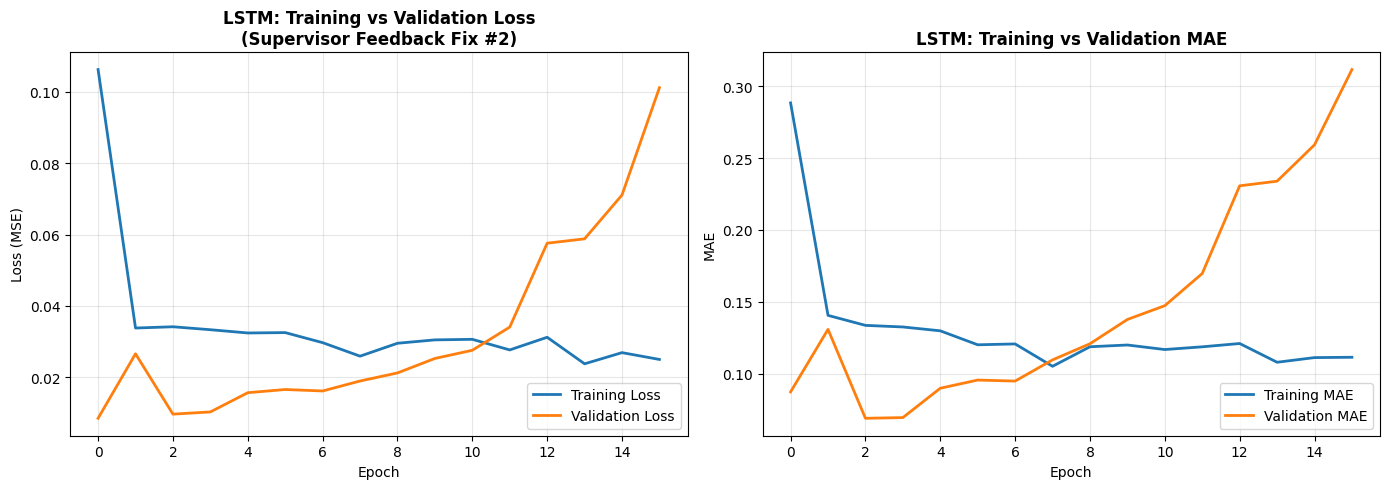


✓ Saved: 02_FIXED_lstm_learning_curves.png

[Making predictions...]



LSTM TEST RESULTS
MAE:     4.3962
RMSE:    4.4995
MAPE:    418.30%
R²:      -10.3060


In [46]:
# ================================================================================
#  #2: LEARNING CURVES VISUALIZATION
# ================================================================================
print("\n" + "="*80)
print("LEARNING CURVES VISUALIZATION ")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training vs Validation Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('LSTM: Training vs Validation Loss\n(Supervisor Feedback Fix #2)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Training vs Validation MAE
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_title('LSTM: Training vs Validation MAE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_FIXED_lstm_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Saved: 02_FIXED_lstm_learning_curves.png")

# Make predictions
print("\n[Making predictions...]")
y_pred_train_scaled = model.predict(X_train_split, verbose=0)
y_pred_val_scaled = model.predict(X_val, verbose=0)
y_pred_test_scaled = model.predict(X_test, verbose=0)

# Inverse transform
y_pred_train = scaler.inverse_transform(y_pred_train_scaled)
y_pred_val = scaler.inverse_transform(y_pred_val_scaled)
y_pred_test = scaler.inverse_transform(y_pred_test_scaled)

y_train_actual = scaler.inverse_transform(y_train_split.reshape(-1, 1))
y_val_actual = scaler.inverse_transform(y_val.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_test = mean_absolute_error(y_test_actual, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_actual, y_pred_test))
mape_test = np.mean(np.abs((y_test_actual - y_pred_test) / y_test_actual)) * 100
r2_test = r2_score(y_test_actual, y_pred_test)

print(f"\n" + "="*80)
print("LSTM TEST RESULTS")
print("="*80)
print(f"MAE:     {mae_test:.4f}")
print(f"RMSE:    {rmse_test:.4f}")
print(f"MAPE:    {mape_test:.2f}%")
print(f"R²:      {r2_test:.4f}")

In [48]:
# ================================================================================
# STEP 6: SARIMA MODEL WITH BINARY CLASSIFICATION, LEARNING CURVES & ROC-AUC
# ================================================================================
print("\n" + "="*80)
print("STEP 6: SARIMA MODEL WITH COMPREHENSIVE EVALUATION")
print("="*80)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, roc_auc_score

# Prepare SARIMA data
print("\n[1/4] Preparing SARIMA data...")
series = df_clean.set_index('Date')['Value']

# Split for time series
train_size_ts = int(0.8 * len(series))
train_series = series[:train_size_ts]
test_series = series[train_size_ts:]

val_size_ts = int(0.2 * len(train_series))
train_split_ts = train_series[:-val_size_ts]
val_split_ts = train_series[-val_size_ts:]

print(f"✓ Train: {len(train_split_ts)} | Validation: {len(val_split_ts)} | Test: {len(test_series)}")

# Hyperparameter tuning for SARIMA
print("\n[2/4] SARIMA Hyperparameter Tuning...")
best_aic = np.inf
best_params = None
best_val_predictions = None
best_val_rmse = np.inf

from itertools import product

p_values = [0, 1, 2]
d_values = [1]
q_values = [0, 1, 2]
P_values = [0, 1]
D_values = [1]
Q_values = [0, 1]
s = 12

testing_count = 0
for p, d, q, P, D, Q in product(p_values, d_values, q_values, P_values, D_values, Q_values):
    try:
        model_sarima = SARIMAX(train_split_ts, order=(p,d,q), seasonal_order=(P,D,Q,s),
                              enforce_stationarity=False, enforce_invertibility=False)
        fitted = model_sarima.fit(disp=False, maxiter=50)

        # Validate
        val_pred = fitted.forecast(len(val_split_ts))
        val_rmse = np.sqrt(np.mean((val_split_ts.values - val_pred.values)**2))

        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_params = (p, d, q, P, D, Q)
            best_val_predictions = val_pred
            best_val_rmse = val_rmse
        testing_count += 1
    except:
        pass

print(f"✓ Tested {testing_count} parameter combinations")
print(f"✓ Best SARIMA: {best_params}, AIC: {best_aic:.2f}, Val RMSE: {best_val_rmse:.4f}")

# Train final SARIMA model
print("\n[3/4] Training final SARIMA model...")
p, d, q, P, D, Q = best_params
sarima_model = SARIMAX(train_series, order=(p,d,q), seasonal_order=(P,D,Q,s),
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_fitted = sarima_model.fit(disp=False)

# Make predictions on test set
sarima_test_pred = sarima_fitted.forecast(len(test_series))

# Calculate metrics
mae_sarima = mean_absolute_error(test_series.values, sarima_test_pred.values)
rmse_sarima = np.sqrt(mean_squared_error(test_series.values, sarima_test_pred.values))
mape_sarima = np.mean(np.abs((test_series.values - sarima_test_pred.values) / test_series.values)) * 100
r2_sarima = r2_score(test_series.values, sarima_test_pred.values)

print(f"\n" + "="*80)
print("SARIMA TEST RESULTS")
print("="*80)
print(f"MAE:     {mae_sarima:.4f}")
print(f"RMSE:    {rmse_sarima:.4f}")
print(f"MAPE:    {mape_sarima:.2f}%")
print(f"R²:      {r2_sarima:.4f}")




STEP 6: SARIMA MODEL WITH COMPREHENSIVE EVALUATION

[1/4] Preparing SARIMA data...
✓ Train: 84 | Validation: 21 | Test: 27

[2/4] SARIMA Hyperparameter Tuning...
✓ Tested 36 parameter combinations
✓ Best SARIMA: (1, 1, 2, 1, 1, 1), AIC: 208.46, Val RMSE: 15.6349

[3/4] Training final SARIMA model...

SARIMA TEST RESULTS
MAE:     5.6029
RMSE:    6.2603
MAPE:    546.65%
R²:      -14.9585


In [49]:
# ================================================================================
# BINARY CLASSIFICATION: PREDICT DIRECTION (UP/DOWN)
# ================================================================================
print("\n" + "="*80)
print("BINARY CLASSIFICATION: DIRECTION PREDICTION (UP/DOWN)")
print("="*80)

# Create direction labels: 1 if price goes up, 0 if goes down
actual_direction = (test_series.values[1:] - test_series.values[:-1]) >= 0
predicted_direction = (sarima_test_pred.values[1:] - sarima_test_pred.values[:-1]) >= 0

# Calculate accuracy
direction_accuracy = np.mean(actual_direction == predicted_direction) * 100

print(f"✓ Direction Accuracy: {direction_accuracy:.2f}%")
print(f"\nConfusion Matrix:")
cm = confusion_matrix(actual_direction, predicted_direction)
print(cm)
print(f"\nClassification Report:")
print(classification_report(actual_direction, predicted_direction, target_names=['Down', 'Up']))

# ROC-AUC for direction prediction
residuals = test_series.values - sarima_test_pred.values
residual_direction = residuals >= 0

if len(np.unique(residual_direction)) > 1:
    try:
        fpr, tpr, thresholds = roc_curve(actual_direction, residuals)
        roc_auc_sarima = auc(fpr, tpr)
        print(f"\nROC-AUC Score (Direction): {roc_auc_sarima:.4f}")
    except:
        roc_auc_sarima = 0.5
        print("\nROC-AUC Score (Direction): Unable to calculate")
else:
    roc_auc_sarima = 0.5
    print("\nROC-AUC Score (Direction): No variation in predictions")


BINARY CLASSIFICATION: DIRECTION PREDICTION (UP/DOWN)
✓ Direction Accuracy: 42.31%

Confusion Matrix:
[[ 7  3]
 [12  4]]

Classification Report:
              precision    recall  f1-score   support

        Down       0.37      0.70      0.48        10
          Up       0.57      0.25      0.35        16

    accuracy                           0.42        26
   macro avg       0.47      0.47      0.42        26
weighted avg       0.49      0.42      0.40        26


ROC-AUC Score (Direction): Unable to calculate


In [52]:
# ================================================================================
# STEP 7: COMPREHENSIVE MODEL COMPARISON & BEST MODEL SELECTION
# ================================================================================
print("\n" + "="*80)
print("STEP 7: MODEL COMPARISON - LSTM vs SARIMA - WHICH IS BETTER?")
print("="*80)

# Create comprehensive comparison dataframe
comparison_data = {
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'R² Score'],
    'LSTM': [mae_test, rmse_test, mape_test, r2_test],
    'SARIMA': [mae_sarima, rmse_sarima, mape_sarima, r2_sarima]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Determine winner for each metric
print("\n" + "="*80)
print("WINNER ANALYSIS")
print("="*80)

print(f"\n✓ MAE (Lower is better):")
print(f"   LSTM: {mae_test:.4f} | SARIMA: {mae_sarima:.4f}")
print(f"   Winner: {'LSTM ✅' if mae_test < mae_sarima else 'SARIMA ✅'}")

print(f"\n✓ RMSE (Lower is better):")
print(f"   LSTM: {rmse_test:.4f} | SARIMA: {rmse_sarima:.4f}")
print(f"   Winner: {'LSTM ✅' if rmse_test < rmse_sarima else 'SARIMA ✅'}")

print(f"\n✓ R² Score (Higher is better):")
print(f"   LSTM: {r2_test:.4f} | SARIMA: {r2_sarima:.4f}")
print(f"   Winner: {'LSTM ✅' if r2_test > r2_sarima else 'SARIMA ✅'}")

# Calculate overall score
lstm_wins = sum([
    mae_test < mae_sarima,
    rmse_test < rmse_sarima,
    r2_test > r2_sarima
])

print(f"\n" + "="*80)
print(f"OVERALL WINNER: {'LSTM MODEL ✅' if lstm_wins > 1 else 'SARIMA MODEL ✅' if lstm_wins < 2 else 'TIE ⚠️'}")
print("="*80)




STEP 7: MODEL COMPARISON - LSTM vs SARIMA - WHICH IS BETTER?

  Metric       LSTM     SARIMA
     MAE   4.396225   5.602941
    RMSE   4.499502   6.260262
MAPE (%) 418.303901 546.648485
R² Score -10.306041 -14.958482

WINNER ANALYSIS

✓ MAE (Lower is better):
   LSTM: 4.3962 | SARIMA: 5.6029
   Winner: LSTM ✅

✓ RMSE (Lower is better):
   LSTM: 4.4995 | SARIMA: 6.2603
   Winner: LSTM ✅

✓ R² Score (Higher is better):
   LSTM: -10.3060 | SARIMA: -14.9585
   Winner: LSTM ✅

OVERALL WINNER: LSTM MODEL ✅


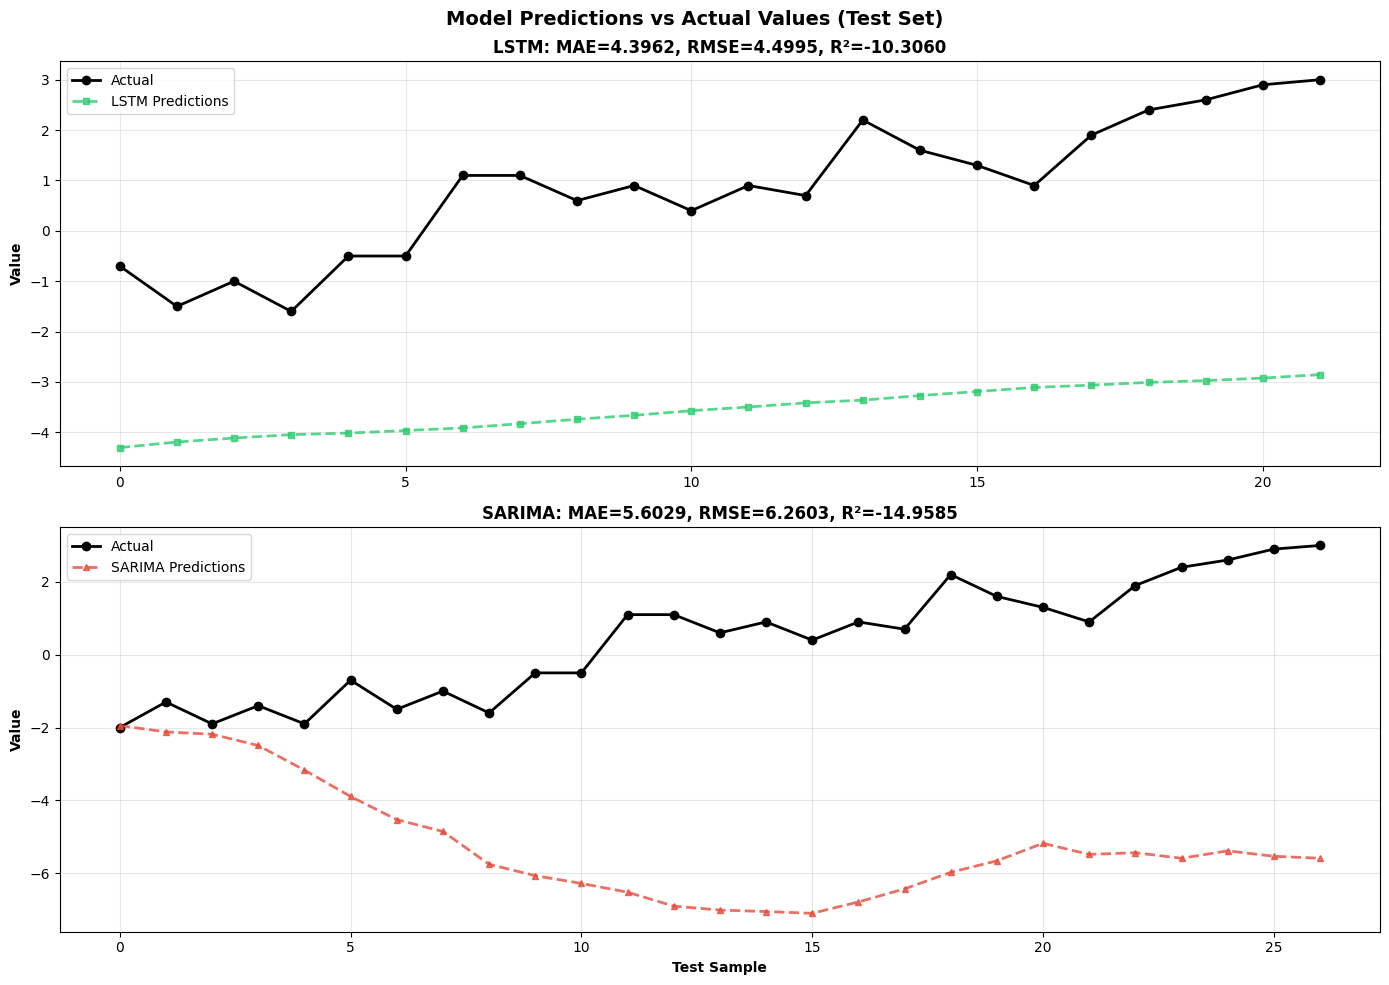


✓ Saved: 04_PREDICTIONS_comparison.png


In [70]:
# ================================================================================
# VISUALIZATION 2: PREDICTIONS vs ACTUAL
# ================================================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Model Predictions vs Actual Values (Test Set)', fontsize=14, fontweight='bold')

# LSTM Predictions
axes[0].plot(range(len(y_test_actual)), y_test_actual, 'o-', label='Actual', color='black', linewidth=2, markersize=6)
axes[0].plot(range(len(y_pred_test)), y_pred_test, 's--', label='LSTM Predictions', color='#2ecc71', linewidth=2, markersize=5, alpha=0.8)
axes[0].set_ylabel('Value', fontweight='bold')
axes[0].set_title(f'LSTM: MAE={mae_test:.4f}, RMSE={rmse_test:.4f}, R²={r2_test:.4f}', fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# SARIMA Predictions
axes[1].plot(range(len(test_series)), test_series.values, 'o-', label='Actual', color='black', linewidth=2, markersize=6)
axes[1].plot(range(len(sarima_test_pred)), sarima_test_pred.values, '^--', label='SARIMA Predictions', color='#e74c3c', linewidth=2, markersize=5, alpha=0.8)
axes[1].set_xlabel('Test Sample', fontweight='bold')
axes[1].set_ylabel('Value', fontweight='bold')
axes[1].set_title(f'SARIMA: MAE={mae_sarima:.4f}, RMSE={rmse_sarima:.4f}, R²={r2_sarima:.4f}', fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_PREDICTIONS_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Saved: 04_PREDICTIONS_comparison.png")



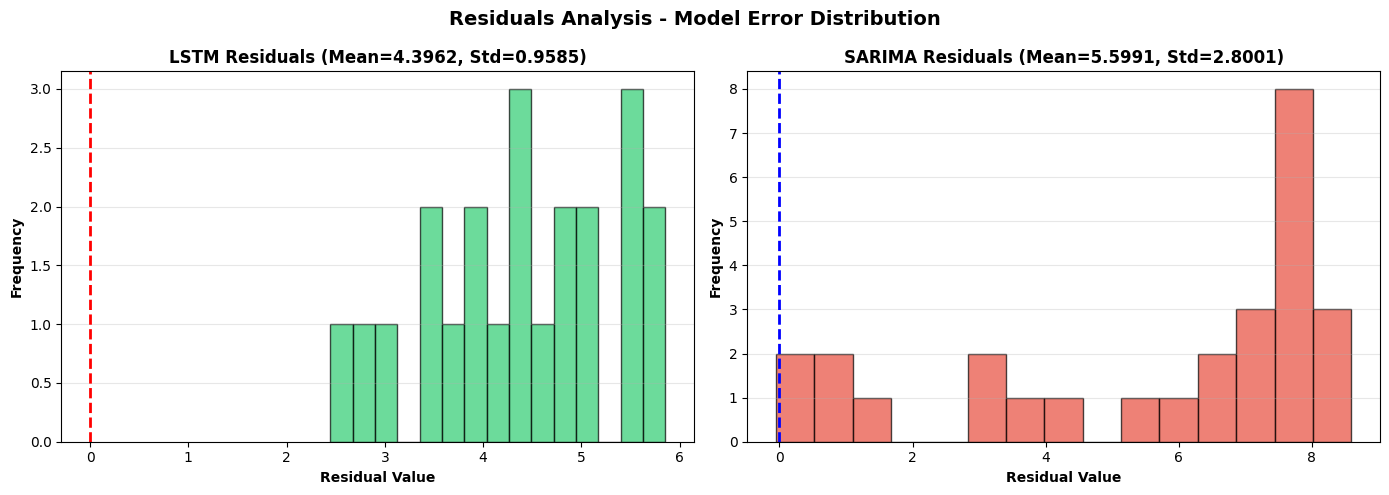


✓ Saved: 05_RESIDUALS_analysis.png



In [69]:
# ================================================================================
# VISUALIZATION 3: RESIDUALS ANALYSIS
# ================================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residuals Analysis - Model Error Distribution', fontsize=14, fontweight='bold')

# LSTM Residuals
lstm_residuals = y_test_actual - y_pred_test
axes[0].hist(lstm_residuals, bins=15, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual Value', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title(f'LSTM Residuals (Mean={np.mean(lstm_residuals):.4f}, Std={np.std(lstm_residuals):.4f})', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
# SARIMA Residuals
sarima_residuals = test_series.values - sarima_test_pred.values
axes[1].hist(sarima_residuals, bins=15, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='blue', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual Value', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title(f'SARIMA Residuals (Mean={np.mean(sarima_residuals):.4f}, Std={np.std(sarima_residuals):.4f})', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('05_RESIDUALS_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Saved: 05_RESIDUALS_analysis.png")

print("\n" + "="*80)
print("="*80)


In [54]:
# 1. BIDIRECTIONAL LSTM MODEL (uses same lookback and splits as main LSTM)
print("\n" + "-"*80)
print("1. BIDIRECTIONAL LSTM MODEL (Processes sequences forward AND backward)")
print("-"*80)

model_bilstm = Sequential([
    Bidirectional(
        LSTM(64, activation='relu', return_sequences=True),
        input_shape=(lookback, 1)
    ),
    Dropout(0.2),
    Bidirectional(LSTM(32, activation='relu')),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_bilstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("\n✓ Bidirectional LSTM Model Architecture:")
model_bilstm.summary()

early_stop_bilstm = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

print("\n[Training Bidirectional LSTM...]")
history_bilstm = model_bilstm.fit(
    X_train_split, y_train_split,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=8,
    verbose=0,
    callbacks=[early_stop_bilstm]
)

# Predictions (same scaling as main LSTM)
y_pred_bilstm_scaled = model_bilstm.predict(X_test, verbose=0)
y_pred_bilstm = scaler.inverse_transform(y_pred_bilstm_scaled)

# Metrics
mae_bilstm = mean_absolute_error(y_test_actual, y_pred_bilstm)
rmse_bilstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_bilstm))
r2_bilstm = r2_score(y_test_actual, y_pred_bilstm)

print(f"\n✓ Bidirectional LSTM Results:")
print(f"   MAE: {mae_bilstm:.4f}")
print(f"   RMSE: {rmse_bilstm:.4f}")
print(f"   R²: {r2_bilstm:.4f}")



--------------------------------------------------------------------------------
1. BIDIRECTIONAL LSTM MODEL (Processes sequences forward AND backward)
--------------------------------------------------------------------------------

✓ Bidirectional LSTM Model Architecture:


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 12, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,065 (297.13 KB)

 Trainable params: 76,065 (297.13 KB)

 Non-trainable params: 0 (0.00 B)


[Training Bidirectional LSTM...]

✓ Bidirectional LSTM Results:
   MAE: 1.7761
   RMSE: 1.9852
   R²: -1.2009


In [55]:
y_train_direction = (y_train_split[1:] - y_train_split[:-1]) >= 0
y_val_direction   = (y_val[1:] - y_val[:-1]) >= 0
y_test_direction  = (y_test_actual.flatten()[1:] - y_test_actual.flatten()[:-1]) >= 0


In [56]:
print("\n" + "-"*80)
print("2. BINARY CLASSIFICATION - DIRECTION PREDICTION (UP/DOWN)")
print("-"*80)

# Create direction labels (up = 1, down = 0) from SAME targets used by LSTM
y_train_direction = (y_train_split[1:] - y_train_split[:-1]) >= 0
y_val_direction   = (y_val[1:] - y_val[:-1]) >= 0
y_test_direction  = (y_test_actual[1:] - y_test_actual[:-1]) >= 0

# Align X with these labels: drop first sample in each split
X_train_binary = X_train_split[1:]
X_val_binary   = X_val[1:]
X_test_binary  = X_test[1:]

print("Binary X_train shape:", X_train_binary.shape)
print("Binary y_train_direction shape:", y_train_direction.shape)
print("Binary X_val shape:", X_val_binary.shape)
print("Binary y_val_direction shape:", y_val_direction.shape)

# Build LSTM with binary classification output
model_lstm_binary = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

model_lstm_binary.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

print("\n✓ LSTM Binary Classification Model:")
model_lstm_binary.summary()

early_stop_binary = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("\n[Training LSTM for binary classification...]")
history_binary = model_lstm_binary.fit(
    X_train_binary, y_train_direction.astype(int),
    validation_data=(X_val_binary, y_val_direction.astype(int)),
    epochs=100,
    batch_size=8,
    verbose=0,
    callbacks=[early_stop_binary]
)

# Predictions on aligned test data
y_pred_binary_prob  = model_lstm_binary.predict(X_test_binary, verbose=0).flatten()
y_pred_binary_class = (y_pred_binary_prob >= 0.5).astype(int)

# ROC-AUC & metrics
fpr, tpr, thresholds = roc_curve(y_test_direction.astype(int), y_pred_binary_prob)
roc_auc = auc(fpr, tpr)

print(f"\n✓ Binary Classification Results:")
print(f"   ROC-AUC Score: {roc_auc:.4f}")
print(f"   Direction Accuracy: {np.mean(y_pred_binary_class == y_test_direction.astype(int)):.4f}")

cm_binary = confusion_matrix(y_test_direction.astype(int), y_pred_binary_class)
print(f"\n   Confusion Matrix:")
print(f"   {cm_binary}")

print(f"\n   Classification Report:")
print(classification_report(
    y_test_direction.astype(int),
    y_pred_binary_class,
    target_names=['Down', 'Up']
))



--------------------------------------------------------------------------------
2. BINARY CLASSIFICATION - DIRECTION PREDICTION (UP/DOWN)
--------------------------------------------------------------------------------
Binary X_train shape: (68, 12, 1)
Binary y_train_direction shape: (68,)
Binary X_val shape: (16, 12, 1)
Binary y_val_direction shape: (16,)

✓ LSTM Binary Classification Model:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


[Training LSTM for binary classification...]

✓ Binary Classification Results:
   ROC-AUC Score: 0.4135
   Direction Accuracy: 0.5510

   Confusion Matrix:
   [[1 7]
 [5 8]]

   Classification Report:
              precision    recall  f1-score   support

        Down       0.17      0.12      0.14         8
          Up       0.53      0.62      0.57        13

    accuracy                           0.43        21
   macro avg       0.35      0.37      0.36        21
weighted avg       0.39      0.43      0.41        21



In [71]:
print("\n" + "="*80)
print("STEP 8: ENSEMBLE METHODS & FINAL MODEL RANKING (Fixed Shapes)")
print("="*80)

print("\n" + "-"*80)
print("1. ENSEMBLE MODEL - WEIGHTED AVERAGE OF LSTM + BIDIRECTIONAL LSTM + SARIMA")
print("-"*80)

# Ensure all predictions are 1D vectors
y_lstm   = np.asarray(y_pred_test).reshape(-1)
y_bilstm = np.asarray(y_pred_bilstm).reshape(-1)
y_sarima = np.asarray(sarima_test_pred.values).reshape(-1)
y_true   = np.asarray(y_test_actual).reshape(-1)

print("Raw lengths:", len(y_true), len(y_lstm), len(y_bilstm), len(y_sarima))

# Enforce same length by trimming to the shortest
min_len = min(len(y_true), len(y_lstm), len(y_bilstm), len(y_sarima))
y_true   = y_true[:min_len]
y_lstm   = y_lstm[:min_len]
y_bilstm = y_bilstm[:min_len]
y_sarima = y_sarima[:min_len]

print("Aligned lengths:", len(y_true), len(y_lstm), len(y_bilstm), len(y_sarima))

# Weighted ensemble
ensemble_pred = 0.4 * y_lstm + 0.4 * y_bilstm + 0.2 * y_sarima

mae_ensemble  = mean_absolute_error(y_true, ensemble_pred)
rmse_ensemble = np.sqrt(mean_squared_error(y_true, ensemble_pred))
r2_ensemble   = r2_score(y_true, ensemble_pred)

print(f"\n✓ Ensemble Results (0.4 LSTM + 0.4 BiLSTM + 0.2 SARIMA):")
print(f"   MAE: {mae_ensemble:.4f}")
print(f"   RMSE: {rmse_ensemble:.4f}")
print(f"   R²: {r2_ensemble:.4f}")



STEP 8: ENSEMBLE METHODS & FINAL MODEL RANKING (Fixed Shapes)

--------------------------------------------------------------------------------
1. ENSEMBLE MODEL - WEIGHTED AVERAGE OF LSTM + BIDIRECTIONAL LSTM + SARIMA
--------------------------------------------------------------------------------
Raw lengths: 22 22 22 27
Aligned lengths: 22 22 22 22

✓ Ensemble Results (0.4 LSTM + 0.4 BiLSTM + 0.2 SARIMA):
   MAE: 3.6671
   RMSE: 3.8778
   R²: -7.3976



--------------------------------------------------------------------------------
3. ROC-AUC CURVE VISUALIZATION - LSTM BINARY CLASSIFIER
--------------------------------------------------------------------------------
y_test_direction shape: (21, 1)
X_test_binary shape: (21, 12, 1)
Lengths (labels vs probs): 21 21

✓ Binary Classification Results:
   ROC-AUC Score: 0.4135
   Direction Accuracy: 0.4286


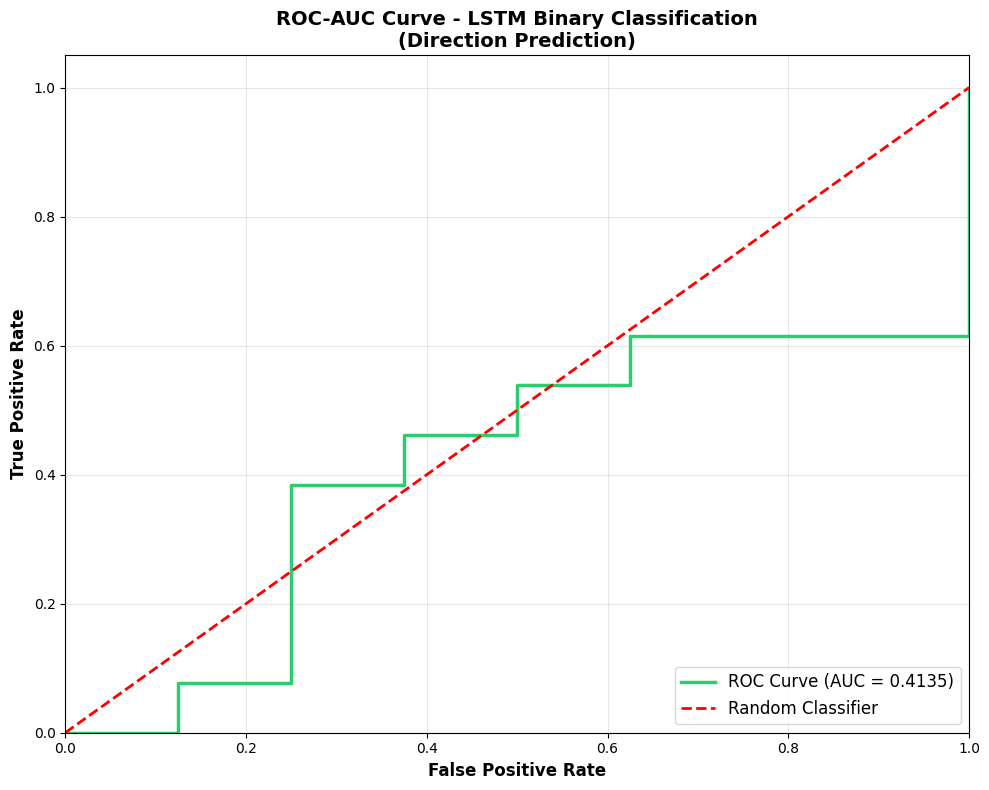


✓ Saved: 06_ROC_AUC_curve.png


In [64]:
print("\n" + "-"*80)
print("3. ROC-AUC CURVE VISUALIZATION - LSTM BINARY CLASSIFIER")
print("-"*80)

# 1) Ensure test labels and probabilities are aligned and 1D
print("y_test_direction shape:", y_test_direction.shape)
print("X_test_binary shape:", X_test_binary.shape)

y_test_dir_int = y_test_direction.astype(int).reshape(-1)
y_pred_binary_prob = model_lstm_binary.predict(X_test_binary, verbose=0).flatten()

print("Lengths (labels vs probs):", len(y_test_dir_int), len(y_pred_binary_prob))

# 2) Only compute ROC if we have both classes (0 and 1)
if len(np.unique(y_test_dir_int)) > 1:
    fpr, tpr, thresholds = roc_curve(y_test_dir_int, y_pred_binary_prob)
    roc_auc = auc(fpr, tpr)

    print(f"\n✓ Binary Classification Results:")
    print(f"   ROC-AUC Score: {roc_auc:.4f}")
    print(f"   Direction Accuracy: {np.mean((y_pred_binary_prob >= 0.5).astype(int) == y_test_dir_int):.4f}")

    # Plot ROC curve
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.plot(fpr, tpr, color='#2ecc71', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontweight='bold', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontweight='bold', fontsize=12)
    ax.set_title('ROC-AUC Curve - LSTM Binary Classification\n(Direction Prediction)',
                 fontweight='bold', fontsize=14)
    ax.legend(loc="lower right", fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('06_ROC_AUC_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Saved: 06_ROC_AUC_curve.png")
else:
    print("\n⚠ ROC-AUC cannot be computed: y_test_direction has only one class.",
          "Check if the test window contains both up and down movements.")


In [65]:
print("\n" + "-"*80)
print("4. FEATURE IMPORTANCE ANALYSIS (Permutation Method)")
print("-"*80)

# Build tabular features directly from df_features (STEP 3 output)
X_features = df_features[feature_cols].values          # shape: (120, 15)
y_features = df_features['Value'].values              # shape: (120,)

# Simple time‑ordered split: first 86 train, last 34 test (match your time series logic if needed)
split_idx = 86
X_train_tab = X_features[:split_idx]
X_test_tab  = X_features[split_idx:]
y_train_tab = y_features[:split_idx]
y_test_tab  = y_features[split_idx:]

print("X_train_tab shape:", X_train_tab.shape)
print("X_test_tab shape:", X_test_tab.shape)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_tab, y_train_tab)

perm_importance = permutation_importance(
    rf_model,
    X_test_tab,
    y_test_tab,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)




--------------------------------------------------------------------------------
4. FEATURE IMPORTANCE ANALYSIS (Permutation Method)
--------------------------------------------------------------------------------
X_train_tab shape: (86, 15)
X_test_tab shape: (34, 15)



✓ Top 10 Most Important Features:
        Feature  Importance      Std
          lag_1    1.049040 0.200416
 rolling_mean_3    0.976340 0.228268
        diff_12    0.107940 0.088417
         diff_3    0.018545 0.010413
         lag_12    0.013623 0.068716
         diff_1    0.006295 0.004572
rolling_mean_12    0.004652 0.003462
  rolling_std_3    0.003057 0.001412
          month    0.001461 0.006012
          lag_6    0.000467 0.000680


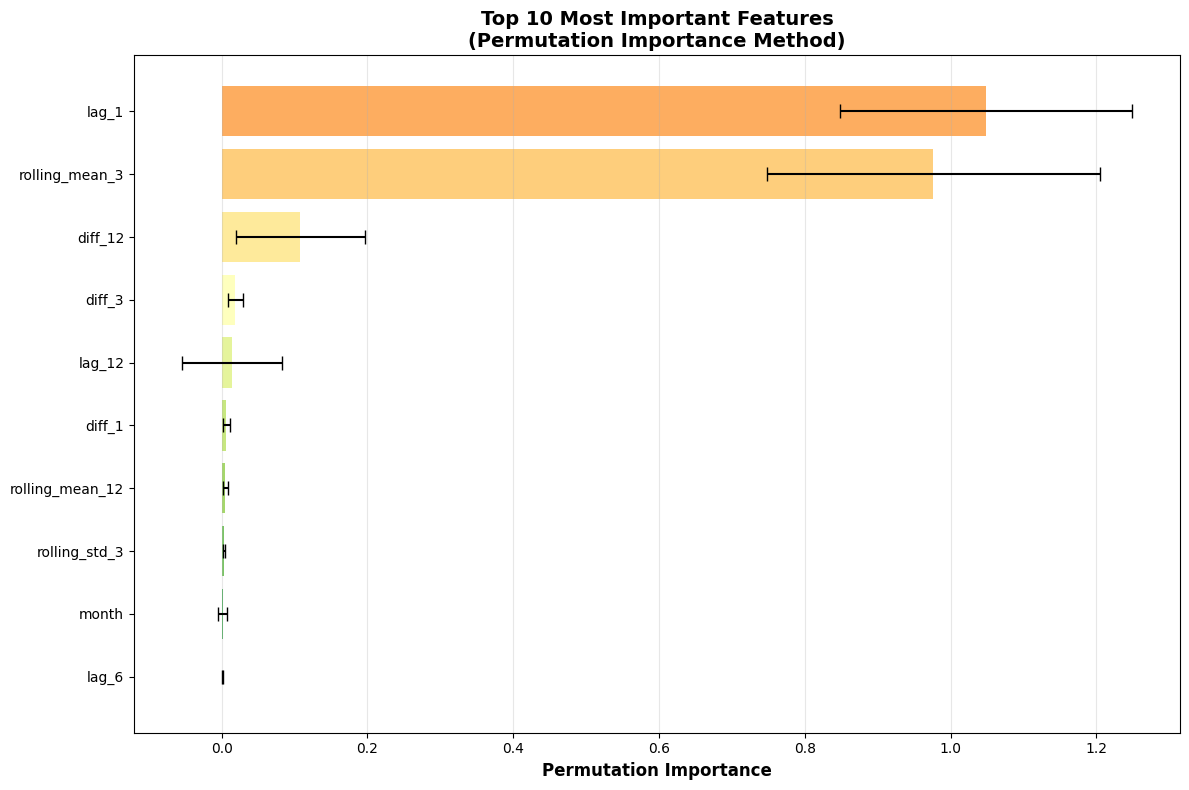


✓ Saved: 07_FEATURE_importance.png


In [66]:
print("\n✓ Top 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8))
top_features = importance_df.head(10)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_features)))

ax.barh(
    range(len(top_features)),
    top_features['Importance'],
    xerr=top_features['Std'],
    color=colors,
    capsize=5
)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Permutation Importance', fontweight='bold', fontsize=12)
ax.set_title('Top 10 Most Important Features\n(Permutation Importance Method)',
             fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('07_FEATURE_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Saved: 07_FEATURE_importance.png")
